## Baseline Model — Multiclass Softmax Regression

This notebook trains a baseline multiclass model for flight delay prediction using **Softmax Regression**.

The goal is to predict the arrival delay class of a flight using three categories:

- **Class 0 — On time:** flights with no arrival delay or early arrival (`arr_delay_min <= 0`)
- **Class 1 — Delay up to 60 minutes:** flights with arrival delay from 1 to 60 minutes (`1 <= arr_delay_min <= 60`)
- **Class 2 — Severe delay:** flights with arrival delay greater than 60 minutes (`arr_delay_min > 60`)



In [1]:
import pandas as pd
import numpy as np
import pyarrow


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

print(pyarrow.__version__)

24.0.0


# 2. Load Dataset

In [2]:
data = pd.read_parquet(
    "/Users/Cliscia-Aula/Downloads/flights_with_weather.parquet"
)

data.shape

(2967376, 31)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2967376 entries, 0 to 2967375
Data columns (total 31 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   airline_icao                     str           
 1   origin_icao                      str           
 2   destination_icao                 str           
 3   dep_scheduled                    datetime64[us]
 4   dep_actual                       str           
 5   arr_scheduled                    datetime64[us]
 6   arr_actual                       str           
 7   origin_type                      str           
 8   origin_lat                       float64       
 9   origin_lon                       float64       
 10  origin_elevation_ft              float64       
 11  origin_region                    str           
 12  destination_type                 str           
 13  destination_lat                  float64       
 14  destination_lon                  float64     

In [6]:
data.columns.tolist()

['airline_icao',
 'origin_icao',
 'destination_icao',
 'dep_scheduled',
 'dep_actual',
 'arr_scheduled',
 'arr_actual',
 'origin_type',
 'origin_lat',
 'origin_lon',
 'origin_elevation_ft',
 'origin_region',
 'destination_type',
 'destination_lat',
 'destination_lon',
 'destination_elevation_ft',
 'destination_region',
 'origin_wx_temperature_2m',
 'origin_wx_precipitation',
 'origin_wx_windspeed_10m',
 'origin_wx_windgusts_10m',
 'origin_wx_cloudcover',
 'origin_wx_weathercode',
 'origin_wx_surface_pressure',
 'destination_wx_temperature_2m',
 'destination_wx_precipitation',
 'destination_wx_windspeed_10m',
 'destination_wx_windgusts_10m',
 'destination_wx_cloudcover',
 'destination_wx_weathercode',
 'destination_wx_surface_pressure']

# Create arrival delay in minutes

In [7]:
# Convert datetime columns
data["arr_scheduled"] = pd.to_datetime(data["arr_scheduled"])
data["arr_actual"] = pd.to_datetime(data["arr_actual"])

# Arrival delay in minutes
data["arr_delay_min"] = (
    data["arr_actual"] - data["arr_scheduled"]
).dt.total_seconds() / 60

In [8]:
def create_target(delay):
    if delay <= 0:
        return 0
    elif delay <= 60:
        return 1
    else:
        return 2


data["target"] = data["arr_delay_min"].apply(create_target)

In [9]:
data[["arr_scheduled", "arr_actual", "arr_delay_min", "target"]].head()

,arr_scheduled,arr_actual,arr_delay_min,target
0,2022-01-06 15:25:00,2022-01-06 15:29:00,4.0,1
1,2022-01-07 15:25:00,2022-01-07 15:42:00,17.0,1
2,2022-01-08 15:25:00,2022-01-08 15:12:00,-13.0,0
3,2022-01-09 15:25:00,2022-01-09 15:15:00,-10.0,0
4,2022-01-11 15:25:00,2022-01-11 15:15:00,-10.0,0


In [10]:
data["target"].value_counts()

target
0    1845141
1    1037039
2      85196
Name: count, dtype: int64

# Feature Engineering

In [11]:
# Convert scheduled departure to datetime
data["dep_scheduled"] = pd.to_datetime(data["dep_scheduled"])

# Basic temporal features
data["dep_hour"] = data["dep_scheduled"].dt.hour
data["dep_minute"] = data["dep_scheduled"].dt.minute
data["dep_day_of_week"] = data["dep_scheduled"].dt.dayofweek
data["dep_month"] = data["dep_scheduled"].dt.month
data["dep_day_of_year"] = data["dep_scheduled"].dt.dayofyear

# Weekend flag
data["dep_is_weekend"] = data["dep_day_of_week"].isin([5, 6]).astype(int)

In [12]:
# Cyclical encoding
data["dep_hour_sin"] = np.sin(2 * np.pi * data["dep_hour"] / 24)
data["dep_hour_cos"] = np.cos(2 * np.pi * data["dep_hour"] / 24)

data["dep_dow_sin"] = np.sin(2 * np.pi * data["dep_day_of_week"] / 7)
data["dep_dow_cos"] = np.cos(2 * np.pi * data["dep_day_of_week"] / 7)

data["dep_month_sin"] = np.sin(2 * np.pi * data["dep_month"] / 12)
data["dep_month_cos"] = np.cos(2 * np.pi * data["dep_month"] / 12)

In [13]:
# Time block
def get_time_block(hour):
    if 0 <= hour <= 5:
        return "early_morning"
    elif 6 <= hour <= 11:
        return "morning"
    elif 12 <= hour <= 17:
        return "afternoon"
    else:
        return "night"


data["dep_time_block"] = data["dep_hour"].apply(get_time_block)

# Peak hour flag
data["dep_is_peak_hour"] = data["dep_hour"].between(7, 20).astype(int)

## Holiday Feature


In [14]:
import holidays

br_holidays = holidays.Brazil()

data["dep_date"] = data["dep_scheduled"].dt.date

data["dep_is_holiday"] = (
    data["dep_date"]
    .isin(br_holidays)
    .astype(int)
)

In [15]:
data[["dep_scheduled", "dep_date", "dep_is_holiday"]].head()

,dep_scheduled,dep_date,dep_is_holiday
0,2022-01-06 14:20:00,2022-01-06,0
1,2022-01-07 14:20:00,2022-01-07,0
2,2022-01-08 14:20:00,2022-01-08,0
3,2022-01-09 14:20:00,2022-01-09,0
4,2022-01-11 14:20:00,2022-01-11,0


## Route Features

In [16]:
# Route identifier
data["route"] = (
    data["origin_icao"] + "_" + data["destination_icao"]
)

# Region pair
data["region_pair"] = (
    data["origin_region"] + "_" + data["destination_region"]
)

# Same region flag
data["same_region"] = (
    data["origin_region"] == data["destination_region"]
).astype(int)

# Elevation difference
data["elevation_diff_ft"] = (
    data["destination_elevation_ft"] - data["origin_elevation_ft"]
)

In [17]:
data[
    [
        "origin_icao",
        "destination_icao",
        "route",
        "origin_region",
        "destination_region",
        "region_pair",
        "same_region",
        "elevation_diff_ft"
    ]
].head()

,origin_icao,destination_icao,route,origin_region,destination_region,region_pair,same_region,elevation_diff_ft
0,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0
1,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0
2,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0
3,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0
4,SBRJ,SBGR,SBRJ_SBGR,BR-RJ,BR-SP,BR-RJ_BR-SP,0,2450.0


## Distance Features

In [18]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [19]:
data["distance_km"] = haversine(
    data["origin_lat"],
    data["origin_lon"],
    data["destination_lat"],
    data["destination_lon"]
)

In [20]:
data[
    [
        "origin_icao",
        "destination_icao",
        "distance_km"
    ]
].head()

,origin_icao,destination_icao,distance_km
0,SBRJ,SBGR,342.989852
1,SBRJ,SBGR,342.989852
2,SBRJ,SBGR,342.989852
3,SBRJ,SBGR,342.989852
4,SBRJ,SBGR,342.989852


## Flight Range

Classify flights based on their distance

In [21]:
def classify_flight_range(distance):
    if distance < 500:
        return "short"
    elif distance <= 1500:
        return "medium"
    else:
        return "long"


data["flight_range"] = data["distance_km"].apply(classify_flight_range)

In [22]:
data[
    [
        "origin_icao",
        "destination_icao",
        "distance_km",
        "flight_range"
    ]
].head()

,origin_icao,destination_icao,distance_km,flight_range
0,SBRJ,SBGR,342.989852,short
1,SBRJ,SBGR,342.989852,short
2,SBRJ,SBGR,342.989852,short
3,SBRJ,SBGR,342.989852,short
4,SBRJ,SBGR,342.989852,short


## Airport Size Features

In [23]:
airport_size_map = {
    "small_airport": 1,
    "medium_airport": 2,
    "large_airport": 3
}

data["origin_airport_size"] = (
    data["origin_type"]
    .map(airport_size_map)
    .fillna(2)
)

data["destination_airport_size"] = (
    data["destination_type"]
    .map(airport_size_map)
    .fillna(2)
)

In [24]:
data["both_large_airports"] = (
    (data["origin_airport_size"] == 3)
    &
    (data["destination_airport_size"] == 3)
).astype(int)

In [25]:
trunk_routes = [
    "SBRJ_SBGR",
    "SBGR_SBRJ",
    "SBSP_SBRJ",
    "SBRJ_SBSP",
    "SBGR_SBSV",
    "SBSV_SBGR",
    "SBGR_SBRF",
    "SBRF_SBGR"
]

data["is_trunk_route"] = (
    data["route"]
    .isin(trunk_routes)
    .astype(int)
)

In [26]:
data[
    [
        "route",
        "origin_airport_size",
        "destination_airport_size",
        "both_large_airports",
        "is_trunk_route"
    ]
].head()

,route,origin_airport_size,destination_airport_size,both_large_airports,is_trunk_route
0,SBRJ_SBGR,3.0,3.0,1,1
1,SBRJ_SBGR,3.0,3.0,1,1
2,SBRJ_SBGR,3.0,3.0,1,1
3,SBRJ_SBGR,3.0,3.0,1,1
4,SBRJ_SBGR,3.0,3.0,1,1


## Weather Features

In [27]:
def classify_weather(code):

    if code == 0:
        return "clear"

    elif code in [1, 2, 3]:
        return "cloudy"

    elif code in [45, 48]:
        return "fog"

    elif code in [51, 53, 55, 56, 57, 61, 63, 65]:
        return "rain"

    elif code in [71, 73, 75, 77]:
        return "snow"

    elif code in [80, 81, 82]:
        return "showers"

    elif code in [95, 96, 99]:
        return "storm"

    else:
        return "other"

In [28]:
data["origin_wx_condition"] = (
    data["origin_wx_weathercode"]
    .apply(classify_weather)
)

data["destination_wx_condition"] = (
    data["destination_wx_weathercode"]
    .apply(classify_weather)
)

In [29]:
data["origin_wx_is_fog"] = (
    data["origin_wx_weathercode"]
    .isin([45, 48])
    .astype(int)
)

data["origin_wx_is_rain"] = (
    data["origin_wx_weathercode"]
    .isin([51, 53, 55, 56, 57, 61, 63, 65, 80, 81, 82])
    .astype(int)
)

data["origin_wx_is_storm"] = (
    data["origin_wx_weathercode"]
    .isin([95, 96, 99])
    .astype(int)
)

In [30]:
data["destination_wx_is_fog"] = (
    data["destination_wx_weathercode"]
    .isin([45, 48])
    .astype(int)
)

data["destination_wx_is_rain"] = (
    data["destination_wx_weathercode"]
    .isin([51, 53, 55, 56, 57, 61, 63, 65, 80, 81, 82])
    .astype(int)
)

data["destination_wx_is_storm"] = (
    data["destination_wx_weathercode"]
    .isin([95, 96, 99])
    .astype(int)
)

In [31]:
data[
[
    "origin_wx_weathercode",
    "origin_wx_condition",
    "origin_wx_is_fog",
    "origin_wx_is_rain",
    "origin_wx_is_storm",
    "destination_wx_weathercode",
    "destination_wx_condition",
    "destination_wx_is_fog",
    "destination_wx_is_rain",
    "destination_wx_is_storm"
]
].head()

,origin_wx_weathercode,origin_wx_condition,origin_wx_is_fog,origin_wx_is_rain,origin_wx_is_storm,destination_wx_weathercode,destination_wx_condition,destination_wx_is_fog,destination_wx_is_rain,destination_wx_is_storm
0,3.0,cloudy,0,0,0,63.0,rain,0,1,0
1,53.0,rain,0,1,0,61.0,rain,0,1,0
2,53.0,rain,0,1,0,51.0,rain,0,1,0
3,51.0,rain,0,1,0,51.0,rain,0,1,0
4,3.0,cloudy,0,0,0,3.0,cloudy,0,0,0


# Feature Dictionary

##  Features Temporais

Colunas derivadas da data e horário previstos de partida.
 
| Coluna | Tipo | Descrição |
|---------|------|------------|
| `dep_hour` | int | Hora prevista da partida (0-23) |
| `dep_day_of_week` | int | Dia da semana da partida (0=segunda, 6=domingo) |
| `dep_month` | int | Mês da partida |
| `dep_hour_sin` | float | Representação cíclica da hora usando seno |
| `dep_hour_cos` | float | Representação cíclica da hora usando cosseno |
| `dep_dow_sin` | float | Representação cíclica do dia da semana usando seno |
| `dep_dow_cos` | float | Representação cíclica do dia da semana usando cosseno |
| `dep_month_sin` | float | Representação cíclica do mês usando seno |
| `dep_month_cos` | float | Representação cíclica do mês usando cosseno |
| `dep_time_block` | str | Faixa do dia (`early_morning`, `morning`, `afternoon`, `night`) |
| `dep_is_peak_hour` | int (0/1) | Indica se o voo ocorre em horário de pico (7h às 20h) |

## Features de Rota e Região

Colunas derivadas da origem, destino e características geográficas da rota.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `route` | str | Combinação entre aeroporto de origem e destino |
| `origin_region` | str | Região do aeroporto de origem |
| `destination_region` | str | Região do aeroporto de destino |
| `region_pair` | str | Combinação das regiões de origem e destino |
| `same_region` | int (0/1) | Indica se origem e destino pertencem à mesma região |
| `elevation_diff_ft` | float | Diferença de altitude entre os aeroportos em pés |
| `distance_km` | float | Distância aproximada entre os aeroportos em quilômetros |

## Features dos Aeroportos

Colunas relacionadas ao porte dos aeroportos e à importância da rota.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `origin_airport_size` | int | Porte do aeroporto de origem |
| `destination_airport_size` | int | Porte do aeroporto de destino |
| `both_large_airports` | int (0/1) | Indica se ambos os aeroportos são classificados como grandes |
| `is_trunk_route` | int (0/1) | Indica se a rota é uma rota principal de alta movimentação |

## Features de Distância

Colunas relacionadas à distância e às diferenças geográficas entre origem e destino.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `distance_km` | float | Distância aproximada entre os aeroportos em quilômetros |
| `elevation_diff_ft` | float | Diferença de altitude entre os aeroportos em pés |

##  Features dos Aeroportos

Colunas relacionadas ao porte dos aeroportos e à importância da rota.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `origin_airport_size` | int | Porte do aeroporto de origem |
| `destination_airport_size` | int | Porte do aeroporto de destino |
| `both_large_airports` | int (0/1) | Indica se ambos os aeroportos são classificados como grandes |
| `is_trunk_route` | int (0/1) | Indica se a rota é uma rota principal de alta movimentação |

##  Features Meteorológicas

Colunas derivadas das condições climáticas observadas nos aeroportos de origem e destino.

| Coluna | Tipo | Descrição |
|---------|------|------------|
| `origin_wx_temperature_2m` | float | Temperatura do ar na origem (°C) |
| `origin_wx_precipitation` | float | Precipitação na origem (mm) |
| `origin_wx_windspeed_10m` | float | Velocidade do vento na origem (km/h) |
| `origin_wx_windgusts_10m` | float | Rajadas de vento na origem (km/h) |
| `origin_wx_cloudcover` | float | Cobertura de nuvens na origem (%) |
| `origin_wx_weathercode` | int | Código da condição meteorológica na origem |
| `origin_wx_surface_pressure` | float | Pressão atmosférica na origem (hPa) |
| `destination_wx_temperature_2m` | float | Temperatura do ar no destino (°C) |
| `destination_wx_precipitation` | float | Precipitação no destino (mm) |
| `destination_wx_windspeed_10m` | float | Velocidade do vento no destino (km/h) |
| `destination_wx_windgusts_10m` | float | Rajadas de vento no destino (km/h) |
| `destination_wx_cloudcover` | float | Cobertura de nuvens no destino (%) |
| `destination_wx_weathercode` | int | Código da condição meteorológica no destino |
| `destination_wx_surface_pressure` | float | Pressão atmosférica no destino (hPa) |

In [36]:
def create_target(delay):
    if delay <= 0:
        return 0
    elif delay <= 60:
        return 1
    else:
        return 2

data["target"] = data["arr_delay_min"].apply(create_target)

In [37]:
data["target"].value_counts()

target
0    1845141
1    1037039
2      85196
Name: count, dtype: int64

In [38]:
features = [
    # temporais
    "dep_hour_sin",
    "dep_hour_cos",
    "dep_dow_sin",
    "dep_dow_cos",
    "dep_month_sin",
    "dep_month_cos",
    "dep_time_block",
    "dep_is_peak_hour",

    # rota
    "route",
    "origin_region",
    "destination_region",
    "region_pair",
    "same_region",

    # distância
    "distance_km",
    "elevation_diff_ft",

    # aeroportos
    "origin_airport_size",
    "destination_airport_size",
    "both_large_airports",
    "is_trunk_route",

    # clima origem
    "origin_wx_temperature_2m",
    "origin_wx_precipitation",
    "origin_wx_windspeed_10m",
    "origin_wx_windgusts_10m",
    "origin_wx_cloudcover",
    "origin_wx_weathercode",
    "origin_wx_surface_pressure",

    # clima destino
    "destination_wx_temperature_2m",
    "destination_wx_precipitation",
    "destination_wx_windspeed_10m",
    "destination_wx_windgusts_10m",
    "destination_wx_cloudcover",
    "destination_wx_weathercode",
    "destination_wx_surface_pressure"
]

In [ ]:
X = data[features]

y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [40]:
categorical_features = [
    "dep_time_block",
    "route",
    "origin_region",
    "destination_region",
    "region_pair"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [44]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['dep_hour_sin','dep_hour_cos','dep_dow_sin',..., 'destination_wx_cloudcover','destination_wx_weathercode', 'destination_wx_surface_pressure']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dr

In [45]:
y_pred = model.predict(X_test)

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.92      0.76    369029
           1       0.53      0.17      0.26    207408
           2       0.47      0.00      0.00     17039

    accuracy                           0.63    593476
   macro avg       0.55      0.37      0.34    593476
weighted avg       0.60      0.63      0.57    593476



In [48]:
y_prob = model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("ROC AUC:", roc_auc)

ROC AUC: 0.6386240128054893


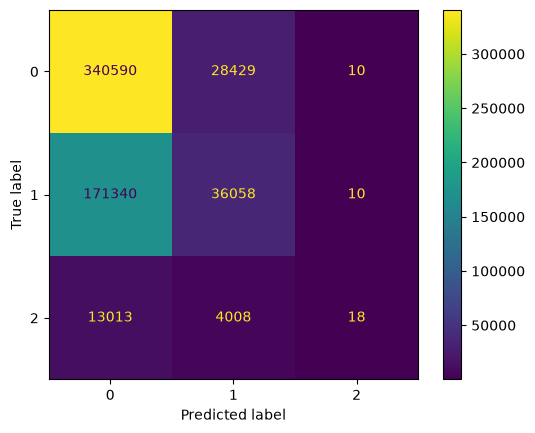

In [49]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [50]:
baseline_results = pd.DataFrame({
    "Model": ["Softmax Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision_weighted": [precision_score(y_test, y_pred, average="weighted")],
    "Recall_weighted": [recall_score(y_test, y_pred, average="weighted")],
    "F1_weighted": [f1_score(y_test, y_pred, average="weighted")],
    "ROC_AUC_weighted": [roc_auc]
})

baseline_results

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC_weighted
0,Softmax Logistic Regression,0.634678,0.601016,0.634678,0.565208,0.638624


## Baseline Results

The Softmax Logistic Regression model was used as the baseline for the multiclass classification problem.

The model achieved:

- Accuracy: 0.63
- Weighted Precision: 0.60
- Weighted Recall: 0.63
- Weighted F1-score: 0.57
- Weighted ROC-AUC: 0.64

The model performed well for class 0 (on-time or early flights), but had difficulty identifying delayed flights, especially class 2 (delays greater than 60 minutes), which received almost zero recall.

This behavior is expected because class 2 is highly underrepresented in the dataset. Therefore, the baseline serves mainly as a reference for future experiments.

Next steps include:

- Creating additional features.
- Testing more powerful algorithms such as LightGBM and CatBoost.
- Evaluating whether the multiclass approach can be improved before considering a binary classification problem.